In [10]:
# ===== Import Libraries yang Digunakan =====

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import butter, filtfilt, find_peaks
from scipy.stats import zscore

In [11]:
# ===== Load Data Kalibrator Insmed =====

ekg_raw = pd.read_csv("/Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/Data Kalibrasi EKG Insmed/Insmed EKG-Konv1.csv")['ekg']
ekg_raw = pd.to_numeric(ekg_raw, errors='coerce').dropna().values

fs = 125  # Sampling frequency kalibrator Insmed
durasi = 10
ekg_10 = ekg_raw[:fs * durasi]
waktu = np.arange(len(ekg_10)) / fs

print(f"Total sampel  : {len(ekg_raw)}")
print(f"Durasi total  : {len(ekg_raw)/fs:.2f} detik")
print(f"Sampel 10 dtk : {len(ekg_10)}")

Total sampel  : 4244
Durasi total  : 33.95 detik
Sampel 10 dtk : 1250


In [12]:
# ===== Preprocessing: Bandpass Filter + DWT Denoising =====

def bandpass_filter(signal_data, lowcut=0.5, highcut=40, fs=125, order=3):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal_data)

def denoise(signal_data):
    coeffs = pywt.wavedec(signal_data, wavelet='db5', level=5)
    coeffs[0] = np.zeros_like(coeffs[0])
    reconstructed = pywt.waverec(coeffs, wavelet='db5')
    return reconstructed[:len(signal_data)]

ekg_bpf = bandpass_filter(ekg_10)
ekg_clean = denoise(ekg_bpf)

In [13]:
# ===== Analisis Frekuensi Sampling =====

dt = 1 / fs  # Interval antar sampel

df_sampling = pd.DataFrame({'Parameter': ['Frekuensi Sampling (fs)', 'Periode Sampling (dt)', 'Jumlah Sampel (10 dtk)', 'Durasi Rekaman'], 'Nilai': [f'{fs} Hz', f'{dt*1000:.2f} ms', f'{len(ekg_10)}', f'{len(ekg_10)/fs:.2f} detik']})
display(df_sampling)

,Parameter,Nilai
0,Frekuensi Sampling (fs),125 Hz
1,Periode Sampling (dt),8.00 ms
2,Jumlah Sampel (10 dtk),1250
3,Durasi Rekaman,10.00 detik


In [ ]:
# ===== Konversi Satuan =====

# Pilih salah satu sesuai spesifikasi alat Insmed:

# Opsi 1: Data dalam µV → konversi ke mV
KONVERSI_INSMED = 1 / 1000  # µV → mV

# Opsi 2: Data dalam raw ADC → konversi ke mV
# KONVERSI_INSMED = (Vref / (2**resolusi_bit)) / gain
# Contoh: Vref=3.3V, 12-bit ADC, gain=1000
# KONVERSI_INSMED = (3.3 / 4096) / 1000 * 1000  # dalam mV

# Terapkan konversi
ekg_10_mV = ekg_10 * KONVERSI_INSMED
ekg_bpf_mV = ekg_bpf * KONVERSI_INSMED
ekg_clean_mV = ekg_clean * KONVERSI_INSMED

print(f"Sebelum konversi: {np.min(ekg_clean):.2f} ~ {np.max(ekg_clean):.2f} (raw)")
print(f"Sesudah konversi: {np.min(ekg_clean_mV):.4f} ~ {np.max(ekg_clean_mV):.4f} mV")
print(f"Peak-to-Peak    : {np.max(ekg_clean_mV) - np.min(ekg_clean_mV):.4f} mV")

,Parameter,Nilai
0,Jumlah R-Peak (10 detik),16
1,BPM (kalibrator),93.5 BPM
2,Mean RR Interval,0.6416 detik
3,Std RR Interval,0.0146 detik


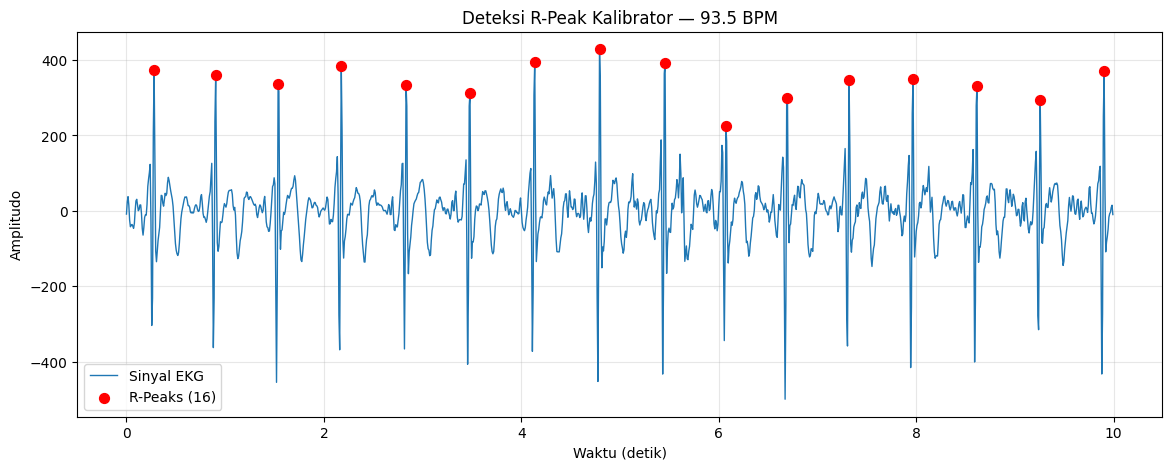

In [14]:
# ===== Analisis Deteksi R-Peak dan BPM =====

from scipy.signal import find_peaks

peaks, properties = find_peaks(ekg_clean, distance=int(0.4 * fs), height=np.mean(ekg_clean))
jumlah_r_peak = len(peaks)
rr_intervals = np.diff(peaks) / fs  # dalam detik
bpm = 60 / np.mean(rr_intervals) if len(rr_intervals) > 0 else 0

df_rpeak = pd.DataFrame({'Parameter': ['Jumlah R-Peak (10 detik)', 'BPM (kalibrator)', 'Mean RR Interval', 'Std RR Interval'], 'Nilai': [f'{jumlah_r_peak}', f'{bpm:.1f} BPM', f'{np.mean(rr_intervals):.4f} detik', f'{np.std(rr_intervals, ddof=1):.4f} detik']})
display(df_rpeak)

plt.figure(figsize=(14, 5))
plt.plot(waktu, ekg_clean, linewidth=1, label='Sinyal EKG')
plt.scatter(waktu[peaks], ekg_clean[peaks], color='red', s=50, zorder=5, label=f'R-Peaks ({jumlah_r_peak})')
plt.title(f'Deteksi R-Peak Kalibrator — {bpm:.1f} BPM')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [15]:
# ===== Analisis Amplitudo Maksimum dan Minimum =====

amp_max_raw = np.max(ekg_10)
amp_min_raw = np.min(ekg_10)
amp_pp_raw = amp_max_raw - amp_min_raw

amp_max_clean = np.max(ekg_clean)
amp_min_clean = np.min(ekg_clean)
amp_pp_clean = amp_max_clean - amp_min_clean

df_amp = pd.DataFrame({'Parameter': ['Amplitudo Maksimum', 'Amplitudo Minimum', 'Peak-to-Peak'], 'Sinyal Asli': [f'{amp_max_raw:.2f}', f'{amp_min_raw:.2f}', f'{amp_pp_raw:.2f}'], 'Setelah Filter': [f'{amp_max_clean:.2f}', f'{amp_min_clean:.2f}', f'{amp_pp_clean:.2f}']})
display(df_amp)

,Parameter,Sinyal Asli,Setelah Filter
0,Amplitudo Maksimum,537.04,428.64
1,Amplitudo Minimum,-486.93,-499.44
2,Peak-to-Peak,1023.97,928.08


,Tahap,SNR (dB),Keterangan
0,Sebelum Filtering (Raw),9.96 dB,Sinyal mentah
1,Setelah BPF,15.37 dB,Bandpass 0.5-40 Hz
2,Setelah BPF + DWT (Final),∞ (referensi),Sinyal paling bersih


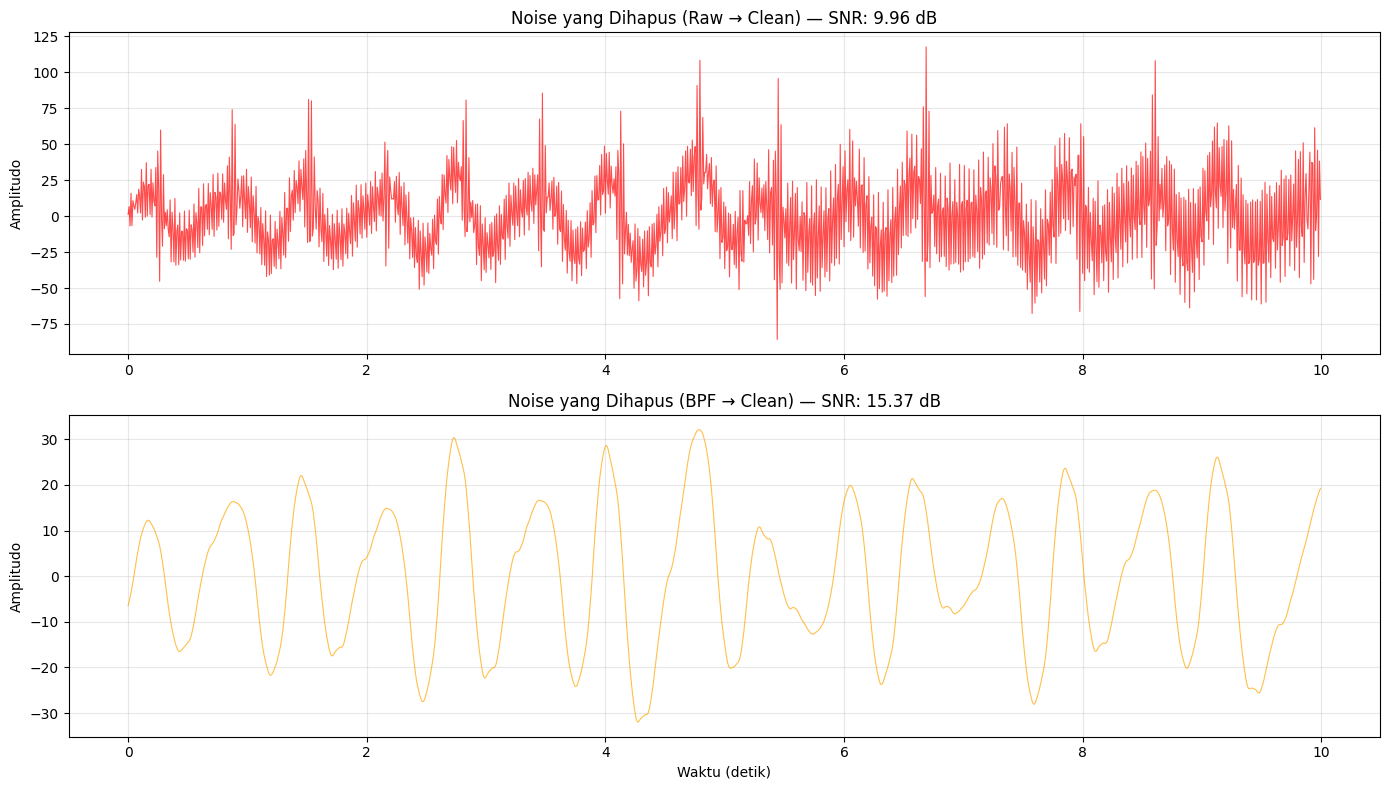

In [16]:
# ===== Analisis SNR Sebelum dan Sesudah Filtering =====

def hitung_snr(signal_asli, signal_bersih):
    noise = signal_asli - signal_bersih
    power_signal = np.mean(signal_bersih ** 2)
    power_noise = np.mean(noise ** 2)
    if power_noise == 0:
        return float('inf')
    snr = 10 * np.log10(power_signal / power_noise)
    return snr

snr_before = hitung_snr(ekg_10, ekg_clean)
snr_after_bpf = hitung_snr(ekg_bpf, ekg_clean)

noise_raw = ekg_10 - ekg_clean
noise_bpf = ekg_bpf - ekg_clean

df_snr = pd.DataFrame({'Tahap': ['Sebelum Filtering (Raw)', 'Setelah BPF', 'Setelah BPF + DWT (Final)'], 'SNR (dB)': [f'{snr_before:.2f} dB', f'{snr_after_bpf:.2f} dB', '∞ (referensi)'], 'Keterangan': ['Sinyal mentah', 'Bandpass 0.5-40 Hz', 'Sinyal paling bersih']})
display(df_snr)

plt.figure(figsize=(14, 8))
plt.subplot(2, 1, 1)
plt.plot(waktu, noise_raw, color='red', alpha=0.7, linewidth=0.8)
plt.title(f'Noise yang Dihapus (Raw → Clean) — SNR: {snr_before:.2f} dB')
plt.ylabel('Amplitudo')
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(waktu, noise_bpf, color='orange', alpha=0.7, linewidth=0.8)
plt.title(f'Noise yang Dihapus (BPF → Clean) — SNR: {snr_after_bpf:.2f} dB')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

,Parameter,Nilai
0,Rentang EKG Standar,50 – 500 mV
1,Amplitudo R-peak (rata-rata),345.86
2,Amplitudo Minimum sinyal,-499.44
3,Peak-to-Peak terukur,845.30
4,Status,⚠️ Di Luar Rentang — periksa satuan/gain ADC


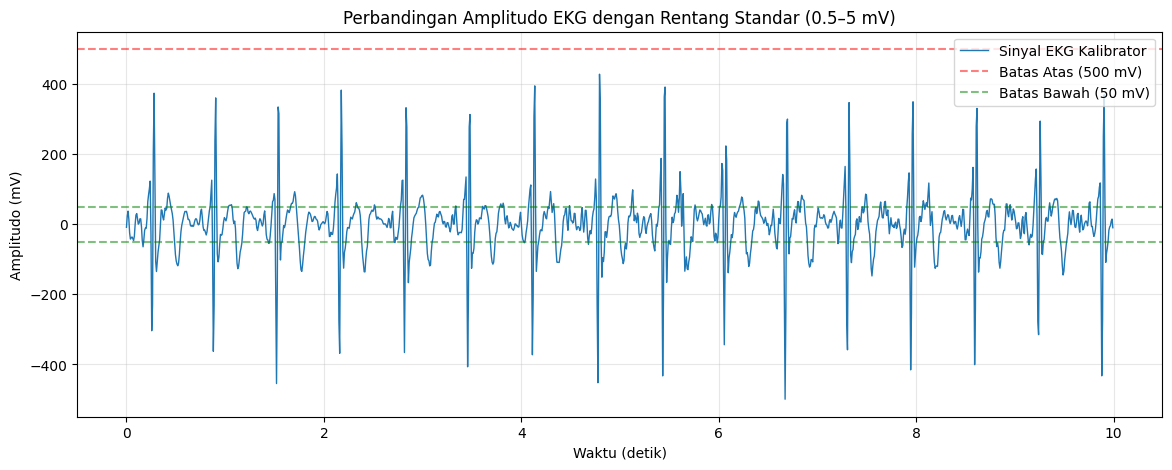

In [27]:
# ===== Analisis Perbandingan dengan Rentang EKG Standar =====

# Rentang amplitudo EKG standar
AMP_MIN_STD = 50   # mV
AMP_MAX_STD = 500   # mV

r_amplitudes = ekg_clean[peaks]
amp_pp_measured = np.mean(r_amplitudes) - np.min(ekg_clean)
dalam_rentang = AMP_MIN_STD <= amp_pp_measured <= AMP_MAX_STD

df_compare = pd.DataFrame({'Parameter': ['Rentang EKG Standar','Amplitudo R-peak (rata-rata)','Amplitudo Minimum sinyal','Peak-to-Peak terukur','Status'],'Nilai': [f'{AMP_MIN_STD} – {AMP_MAX_STD} mV',f'{np.mean(r_amplitudes):.2f}',f'{np.min(ekg_clean):.2f}',f'{amp_pp_measured:.2f}','✅ Dalam Rentang' if dalam_rentang else '⚠️ Di Luar Rentang — periksa satuan/gain ADC']})
display(df_compare)

plt.figure(figsize=(14, 5))
plt.plot(waktu, ekg_clean, linewidth=1, label='Sinyal EKG Kalibrator')
plt.axhline(y=AMP_MAX_STD, color='red', linestyle='--', alpha=0.5, label=f'Batas Atas ({AMP_MAX_STD} mV)')
plt.axhline(y=AMP_MIN_STD, color='green', linestyle='--', alpha=0.5, label=f'Batas Bawah ({AMP_MIN_STD} mV)')
plt.axhline(y=-AMP_MIN_STD, color='green', linestyle='--', alpha=0.5)
plt.title('Perbandingan Amplitudo EKG dengan Rentang Standar (0.5–5 mV)')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo (mV)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

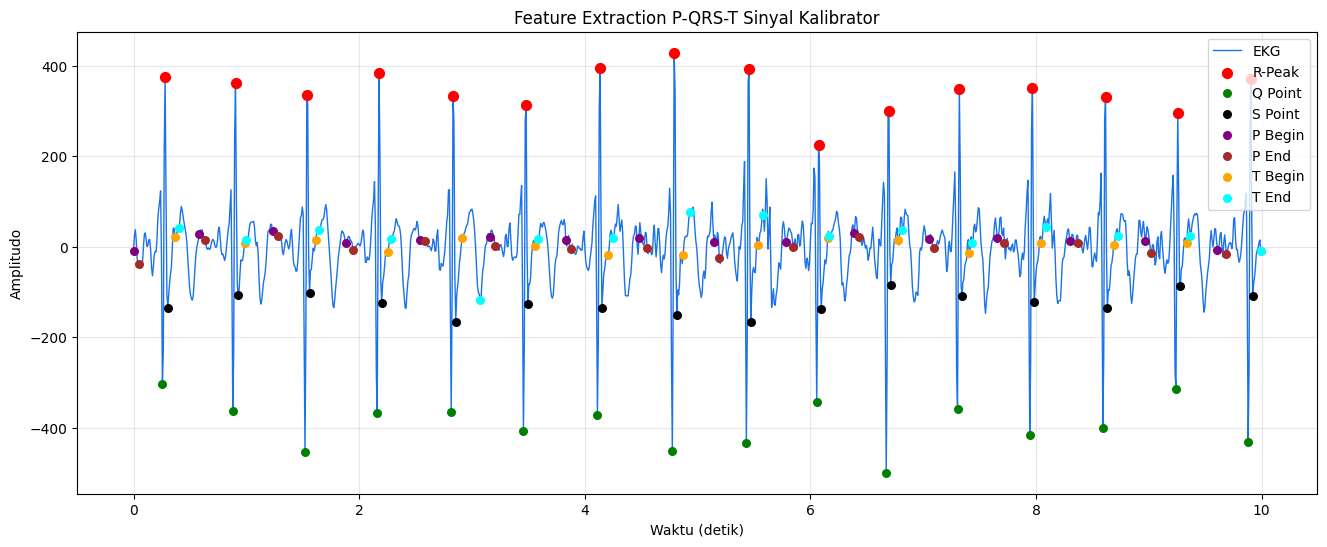

,Beat,P Duration (s),QRS Duration (s),T Duration (s),R Amplitude,RR Interval (s)
0,1,0.0480,0.0480,0.0320,374.37,0.6240
1,2,0.0480,0.0480,0.0160,360.97,0.6320
2,3,0.0480,0.0400,0.0240,335.14,0.6400
3,4,0.0640,0.0400,0.0240,383.13,0.6560
4,5,0.0480,0.0400,0.1600,332.90,0.6480
5,6,0.0480,0.0400,0.0240,313.60,0.6560
6,7,0.0480,0.0400,0.0400,395.26,0.6560
7,8,0.0720,0.0400,0.0640,428.64,0.6640
8,9,0.0480,0.0400,0.0480,392.06,0.6160
9,10,0.0640,0.0400,0.0160,223.85,0.6240


,Fitur,Mean (s),Std (s),Normal Range
0,P-wave Duration,0.0560,0.0113,0.08–0.12 s
1,QRS Duration,0.0410,0.0027,0.06–0.10 s
2,T-wave Duration,0.0390,0.0355,0.10–0.25 s
3,RR Interval,0.6416,0.0146,0.6–1.0 s


In [18]:
# ===== Analisis Feature Extraction P-QRS-T =====

ecg = ekg_clean
time = waktu

# --- Q dan S Points ---
q_points = []
s_points = []
for r_peak in peaks:
    q_start = max(0, r_peak - int(0.08 * fs))
    q_region = ecg[q_start:r_peak]
    if len(q_region) > 0:
        q_points.append(q_start + np.argmin(q_region))

    s_end = min(len(ecg), r_peak + int(0.08 * fs))
    s_region = ecg[r_peak:s_end]
    if len(s_region) > 0:
        s_points.append(r_peak + np.argmin(s_region))

q_points = np.array(q_points, dtype=int)
s_points = np.array(s_points, dtype=int)

# --- P-wave (begin & end) ---
nn = int(0.3 * fs)
interval_der = int(0.02 * fs)
p_wave_begin = []
for q_point in q_points:
    found = False
    for i in range(nn):
        index = q_point - nn + i
        if index < 0 or index + interval_der >= len(ecg):
            continue
        derivative = (ecg[index + interval_der] - ecg[index]) / (time[index + interval_der] - time[index])
        if derivative > 0.5:
            p_wave_begin.append(index)
            found = True
            break
    if not found:
        p_wave_begin.append(max(0, q_point - int(0.12 * fs)))
p_wave_begin = np.array(p_wave_begin, dtype=int)

p_wave_end = []
for p_start in p_wave_begin:
    found = False
    idx = int(0.05 * fs)
    max_search = int(0.15 * fs)
    while not found:
        if p_start + idx + 1 >= len(ecg) or idx >= max_search:
            break
        if ecg[p_start + idx] <= ecg[p_start] and ecg[p_start] > ecg[p_start + idx + 1]:
            p_wave_end.append(p_start + idx)
            found = True
        idx += 1
    if not found:
        p_wave_end.append(min(p_start + int(0.08 * fs), len(ecg) - 1))
p_wave_end = np.array(p_wave_end, dtype=int)

# --- T-wave (begin & end) ---
t_wave_begin = []
t_wave_end = []
for s_point in s_points:
    found = False
    for i in range(int(0.06 * fs), int(0.25 * fs)):
        idx = s_point + i
        if idx + interval_der >= len(ecg):
            break
        d = (ecg[idx + interval_der] - ecg[idx]) / (time[idx + interval_der] - time[idx])
        if d > 0.3:
            t_wave_begin.append(idx)
            found = True
            break
    if not found:
        t_wave_begin.append(min(s_point + int(0.08 * fs), len(ecg) - 1))
    t_start = t_wave_begin[-1]
    found_end = False
    deriv_prev = 0
    for i in range(int(0.3 * fs)):
        idx = t_start + i
        if idx + interval_der >= len(ecg):
            break
        d = (ecg[idx + interval_der] - ecg[idx]) / (time[idx + interval_der] - time[idx])
        if deriv_prev < 0 and d > 0:
            t_wave_end.append(idx)
            found_end = True
            break
        deriv_prev = d
    if not found_end:
        t_wave_end.append(min(t_start + int(0.15 * fs), len(ecg) - 1))

t_wave_begin = np.array(t_wave_begin, dtype=int)
t_wave_end = np.array(t_wave_end, dtype=int)

plt.figure(figsize=(16, 6))
plt.plot(time, ecg, linewidth=1, color='#1a73e8', label='EKG')
plt.scatter(time[peaks], ecg[peaks], color='red', s=50, zorder=5, label='R-Peak')
plt.scatter(time[q_points], ecg[q_points], color='green', s=30, zorder=5, label='Q Point')
plt.scatter(time[s_points], ecg[s_points], color='black', s=30, zorder=5, label='S Point')
plt.scatter(time[p_wave_begin], ecg[p_wave_begin], color='purple', s=30, zorder=5, label='P Begin')
plt.scatter(time[p_wave_end], ecg[p_wave_end], color='brown', s=30, zorder=5, label='P End')
plt.scatter(time[t_wave_begin], ecg[t_wave_begin], color='orange', s=30, zorder=5, label='T Begin')
plt.scatter(time[t_wave_end], ecg[t_wave_end], color='cyan', s=30, zorder=5, label='T End')
plt.title('Feature Extraction P-QRS-T Sinyal Kalibrator')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.show()

min_len = min(len(peaks), len(q_points), len(s_points), len(p_wave_begin), len(p_wave_end), len(t_wave_begin), len(t_wave_end))

fitur_data = []
for i in range(min_len):
    p_dur = (p_wave_end[i] - p_wave_begin[i]) / fs
    qrs_dur = (s_points[i] - q_points[i]) / fs
    t_dur = (t_wave_end[i] - t_wave_begin[i]) / fs
    r_amp = ecg[peaks[i]]
    fitur_data.append({'Beat': i + 1, 'P Duration (s)': f'{p_dur:.4f}', 'QRS Duration (s)': f'{qrs_dur:.4f}', 'T Duration (s)': f'{t_dur:.4f}', 'R Amplitude': f'{r_amp:.2f}', 'RR Interval (s)': f'{rr_intervals[i]:.4f}' if i < len(rr_intervals) else '-'})

df_fitur = pd.DataFrame(fitur_data)
display(df_fitur)

p_durations = [(p_wave_end[i] - p_wave_begin[i]) / fs for i in range(min_len)]
qrs_durations = [(s_points[i] - q_points[i]) / fs for i in range(min_len)]
t_durations = [(t_wave_end[i] - t_wave_begin[i]) / fs for i in range(min_len)]

df_stats = pd.DataFrame({'Fitur': ['P-wave Duration', 'QRS Duration', 'T-wave Duration', 'RR Interval'], 'Mean (s)': [f'{np.mean(p_durations):.4f}', f'{np.mean(qrs_durations):.4f}', f'{np.mean(t_durations):.4f}', f'{np.mean(rr_intervals):.4f}'], 'Std (s)': [f'{np.std(p_durations, ddof=1):.4f}', f'{np.std(qrs_durations, ddof=1):.4f}', f'{np.std(t_durations, ddof=1):.4f}', f'{np.std(rr_intervals, ddof=1):.4f}'], 'Normal Range': ['0.08–0.12 s', '0.06–0.10 s', '0.10–0.25 s', '0.6–1.0 s']})
display(df_stats)

In [19]:
# ===== Load Data Wearable EKG (Kalibrasi) =====

df_wearable = pd.read_csv("/Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/Data Wearable EKG-Konv/Wearable EKG-Konv2_10 Menit.csv")
ekg_w_raw = pd.to_numeric(df_wearable.iloc[:, 2], errors='coerce').dropna().values

fs_w = 250  # Sampling frequency wearable
durasi_w = 10
ekg_w_10 = ekg_w_raw[:fs_w * durasi_w]
waktu_w = np.arange(len(ekg_w_10)) / fs_w

print(f"Total sampel  : {len(ekg_w_raw)}")
print(f"Durasi total  : {len(ekg_w_raw)/fs_w:.2f} detik")
print(f"Sampel 10 dtk : {len(ekg_w_10)}")

Total sampel  : 138995
Durasi total  : 555.98 detik
Sampel 10 dtk : 2500


In [20]:
# ===== Preprocessing Wearable: BPF + DWT =====

ekg_w_bpf = bandpass_filter(ekg_w_10, fs=fs_w, order=3)
ekg_w_clean = denoise(ekg_w_bpf)

In [21]:
# ===== Wearable — Analisis Frekuensi Sampling =====

dt_w = 1 / fs_w

df_sampling_w = pd.DataFrame({'Parameter': ['Frekuensi Sampling (fs)', 'Periode Sampling (dt)', 'Jumlah Sampel (10 dtk)', 'Durasi Rekaman'], 'Kalibrator Insmed': [f'{fs} Hz', f'{1/fs*1000:.2f} ms', f'{len(ekg_10)}', f'{len(ekg_10)/fs:.2f} detik'], 'Wearable EKG': [f'{fs_w} Hz', f'{dt_w*1000:.2f} ms', f'{len(ekg_w_10)}', f'{len(ekg_w_10)/fs_w:.2f} detik']})
display(df_sampling_w)

,Parameter,Kalibrator Insmed,Wearable EKG
0,Frekuensi Sampling (fs),125 Hz,250 Hz
1,Periode Sampling (dt),8.00 ms,4.00 ms
2,Jumlah Sampel (10 dtk),1250,2500
3,Durasi Rekaman,10.00 detik,10.00 detik


,Parameter,Kalibrator Insmed,Wearable EKG
0,Jumlah R-Peak (10 dtk),16,14
1,BPM,93.5 BPM,82.3 BPM
2,Mean RR Interval,0.6416 s,0.7289 s
3,Std RR Interval,0.0146 s,0.0380 s


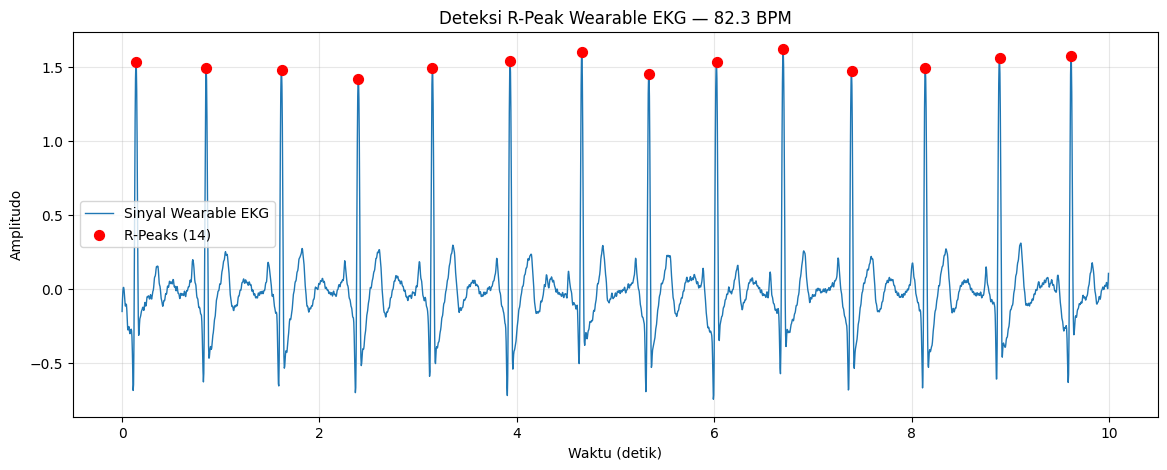

In [ ]:
# ===== Wearable — Analisis R-Peak dan BPM =====

peaks_w, _ = find_peaks(ekg_w_clean, distance=int(0.4 * fs_w), height=np.mean(ekg_w_clean))

jumlah_r_peak_w = len(peaks_w)
rr_intervals_w = np.diff(peaks_w) / fs_w
bpm_w = 60 / np.mean(rr_intervals_w) if len(rr_intervals_w) > 0 else 0

df_rpeak_w = pd.DataFrame({'Parameter': ['Jumlah R-Peak (10 dtk)', 'BPM', 'Mean RR Interval', 'Std RR Interval'], 'Kalibrator Insmed': [f'{jumlah_r_peak}', f'{bpm:.1f} BPM', f'{np.mean(rr_intervals):.4f} s', f'{np.std(rr_intervals, ddof=1):.4f} s'], 'Wearable EKG': [f'{jumlah_r_peak_w}', f'{bpm_w:.1f} BPM', f'{np.mean(rr_intervals_w):.4f} s', f'{np.std(rr_intervals_w, ddof=1):.4f} s']})
display(df_rpeak_w)

plt.figure(figsize=(14, 5))
plt.plot(waktu_w, ekg_w_clean, linewidth=1, label='Sinyal Wearable EKG')
plt.scatter(waktu_w[peaks_w], ekg_w_clean[peaks_w], color='red', s=50, zorder=5, label=f'R-Peaks ({jumlah_r_peak_w})')
plt.title(f'Deteksi R-Peak Wearable EKG — {bpm_w:.1f} BPM')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo (mV)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [23]:
# ===== Wearable — Analisis Amplitudo =====

amp_max_w_raw = np.max(ekg_w_10)
amp_min_w_raw = np.min(ekg_w_10)
amp_pp_w_raw = amp_max_w_raw - amp_min_w_raw

amp_max_w_clean = np.max(ekg_w_clean)
amp_min_w_clean = np.min(ekg_w_clean)
amp_pp_w_clean = amp_max_w_clean - amp_min_w_clean

df_amp_w = pd.DataFrame({'Parameter': ['Amplitudo Maksimum', 'Amplitudo Minimum', 'Peak-to-Peak'], 'Sinyal Asli': [f'{amp_max_w_raw:.4f}', f'{amp_min_w_raw:.4f}', f'{amp_pp_w_raw:.4f}'], 'Setelah Filter': [f'{amp_max_w_clean:.4f}', f'{amp_min_w_clean:.4f}', f'{amp_pp_w_clean:.4f}']})
display(df_amp_w)

,Parameter,Sinyal Asli,Setelah Filter
0,Amplitudo Maksimum,3.2419,1.6197
1,Amplitudo Minimum,1.1194,-0.7480
2,Peak-to-Peak,2.1225,2.3676


,Tahap,SNR Insmed (dB),SNR Wearable (dB)
0,Sebelum Filtering (Raw),9.96,-14.96
1,Setelah BPF,15.37,8.91


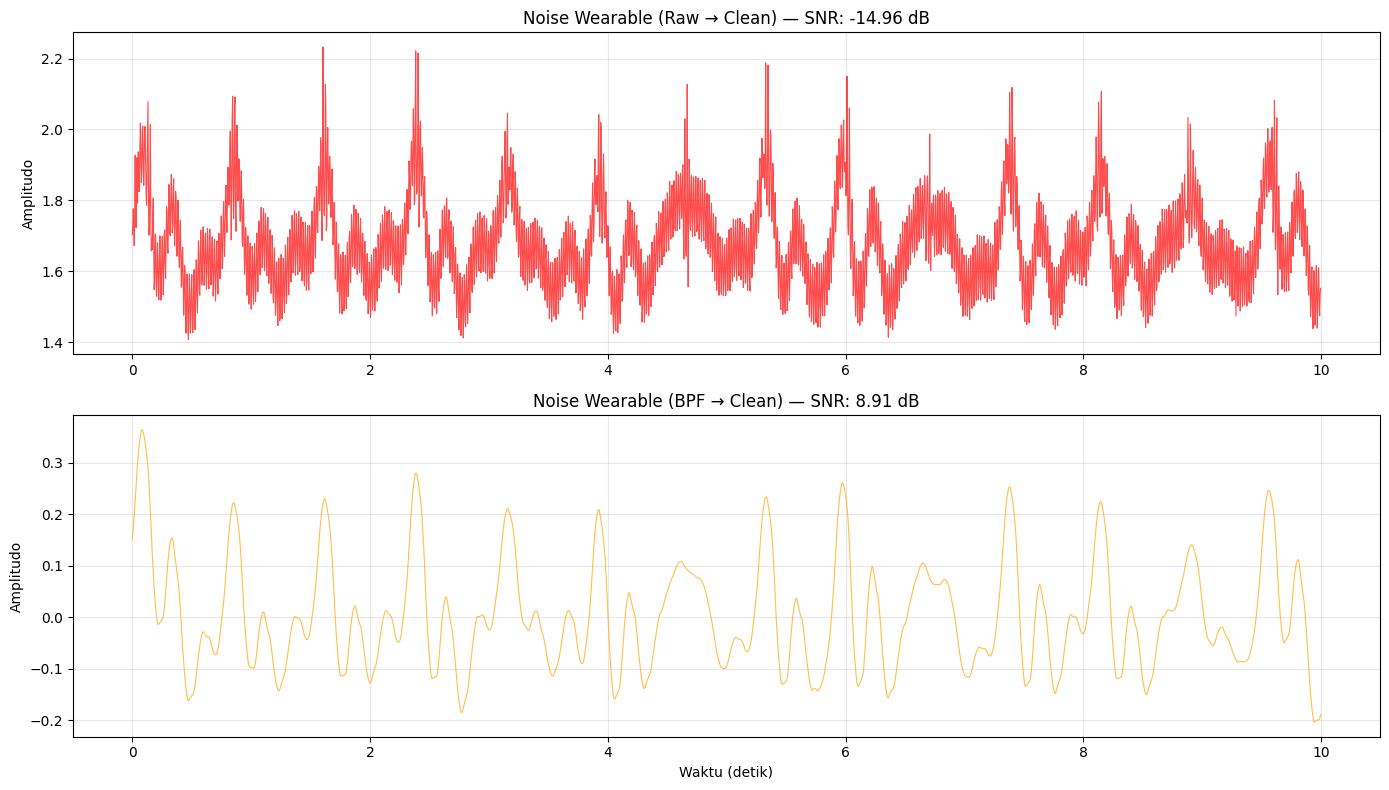

In [24]:
# ===== Wearable — Analisis SNR =====

snr_w_before = hitung_snr(ekg_w_10, ekg_w_clean)
snr_w_after_bpf = hitung_snr(ekg_w_bpf, ekg_w_clean)

noise_w_raw = ekg_w_10 - ekg_w_clean
noise_w_bpf = ekg_w_bpf - ekg_w_clean

df_snr_w = pd.DataFrame({'Tahap': ['Sebelum Filtering (Raw)', 'Setelah BPF'], 'SNR Insmed (dB)': [f'{snr_before:.2f}', f'{snr_after_bpf:.2f}'], 'SNR Wearable (dB)': [f'{snr_w_before:.2f}', f'{snr_w_after_bpf:.2f}']})
display(df_snr_w)

plt.figure(figsize=(14, 8))
plt.subplot(2, 1, 1)
plt.plot(waktu_w, noise_w_raw, color='red', alpha=0.7, linewidth=0.8)
plt.title(f'Noise Wearable (Raw → Clean) — SNR: {snr_w_before:.2f} dB')
plt.ylabel('Amplitudo')
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(waktu_w, noise_w_bpf, color='orange', alpha=0.7, linewidth=0.8)
plt.title(f'Noise Wearable (BPF → Clean) — SNR: {snr_w_after_bpf:.2f} dB')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

,Parameter,Nilai
0,Rentang EKG Standar,0.5 – 5.0 mV
1,Peak-to-Peak Insmed,928.08
2,Peak-to-Peak Wearable,2.2668
3,Status Wearable,✅ Dalam Rentang


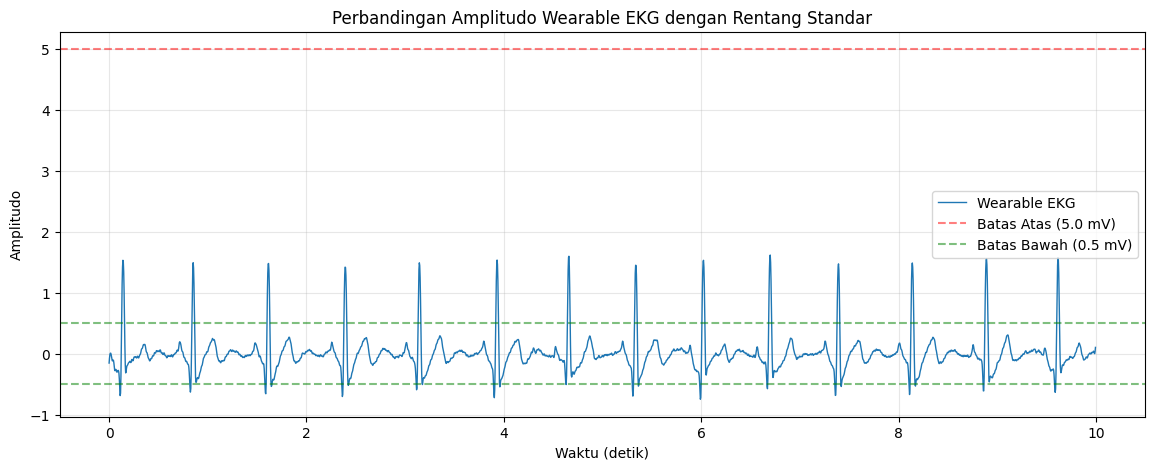

In [25]:
# ===== Wearable — Analisis Perbandingan EKG Standar =====

r_amp_w = ekg_w_clean[peaks_w]
amp_pp_w_measured = np.mean(r_amp_w) - np.min(ekg_w_clean)
dalam_rentang_w = AMP_MIN_STD <= amp_pp_w_measured <= AMP_MAX_STD

df_compare_w = pd.DataFrame({'Parameter': ['Rentang EKG Standar', 'Peak-to-Peak Insmed', 'Peak-to-Peak Wearable', 'Status Wearable'], 'Nilai': [f'{AMP_MIN_STD} – {AMP_MAX_STD} mV', f'{amp_pp_clean:.2f}', f'{amp_pp_w_measured:.4f}', '✅ Dalam Rentang' if dalam_rentang_w else '⚠️ Di Luar Rentang — periksa satuan/gain ADC']})
display(df_compare_w)

plt.figure(figsize=(14, 5))
plt.plot(waktu_w, ekg_w_clean, linewidth=1, label='Wearable EKG')
plt.axhline(y=AMP_MAX_STD, color='red', linestyle='--', alpha=0.5, label=f'Batas Atas ({AMP_MAX_STD} mV)')
plt.axhline(y=AMP_MIN_STD, color='green', linestyle='--', alpha=0.5, label=f'Batas Bawah ({AMP_MIN_STD} mV)')
plt.axhline(y=-AMP_MIN_STD, color='green', linestyle='--', alpha=0.5)
plt.title('Perbandingan Amplitudo Wearable EKG dengan Rentang Standar')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

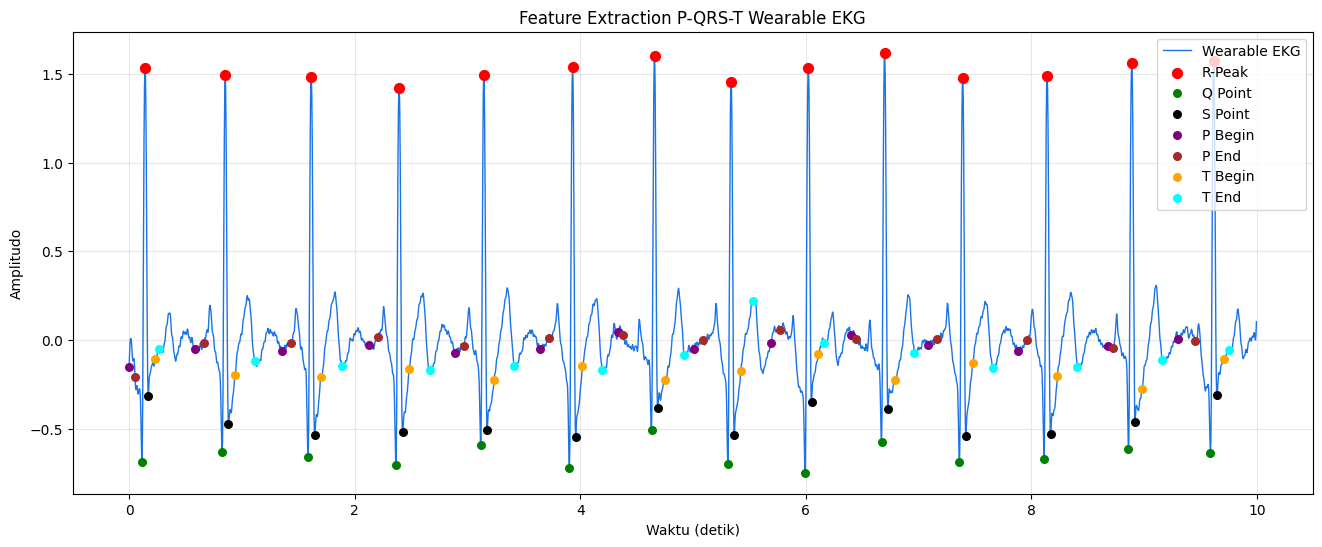

,Beat,P Duration (s),QRS Duration (s),T Duration (s),R Amplitude,RR Interval (s)
0,1,0.0520,0.0560,0.0400,1.5337,0.7120
1,2,0.0800,0.0560,0.1800,1.4938,0.7640
2,3,0.0800,0.0560,0.1840,1.4813,0.7760
3,4,0.0800,0.0600,0.1800,1.4212,0.7520
4,5,0.0800,0.0600,0.1760,1.4920,0.7880
5,6,0.0800,0.0560,0.1760,1.5379,0.7280
6,7,0.0480,0.0560,0.1760,1.6000,0.6760
7,8,0.0800,0.0560,0.1080,1.4523,0.6880
8,9,0.0800,0.0600,0.0520,1.5333,0.6760
9,10,0.0480,0.0560,0.1760,1.6197,0.6920


,Fitur,Insmed (Mean),Wearable (Mean),Normal Range
0,P-wave Duration,0.0560 s,0.0757 s,0.08–0.12 s
1,QRS Duration,0.0410 s,0.0577 s,0.06–0.10 s
2,T-wave Duration,0.0390 s,0.1449 s,0.10–0.25 s
3,RR Interval,0.6416 s,0.7289 s,0.6–1.0 s
4,BPM,93.5,82.3,60–100


In [26]:
# ===== Wearable — Analisis Feature Extraction P-QRS-T =====

ecg_w = ekg_w_clean
time_w = waktu_w

# --- Q dan S ---
q_points_w = []
s_points_w = []
for r_peak in peaks_w:
    q_start = max(0, r_peak - int(0.08 * fs_w))
    q_region = ecg_w[q_start:r_peak]
    if len(q_region) > 0:
        q_points_w.append(q_start + np.argmin(q_region))
    s_end = min(len(ecg_w), r_peak + int(0.08 * fs_w))
    s_region = ecg_w[r_peak:s_end]
    if len(s_region) > 0:
        s_points_w.append(r_peak + np.argmin(s_region))
q_points_w = np.array(q_points_w, dtype=int)
s_points_w = np.array(s_points_w, dtype=int)

# --- P-wave ---
nn_w = int(0.3 * fs_w)
interval_der_w = int(0.02 * fs_w)
p_begin_w = []
for q_point in q_points_w:
    found = False
    for i in range(nn_w):
        index = q_point - nn_w + i
        if index < 0 or index + interval_der_w >= len(ecg_w):
            continue
        d = (ecg_w[index + interval_der_w] - ecg_w[index]) / (time_w[index + interval_der_w] - time_w[index])
        if d > 0.5:
            p_begin_w.append(index)
            found = True
            break
    if not found:
        p_begin_w.append(max(0, q_point - int(0.12 * fs_w)))
p_begin_w = np.array(p_begin_w, dtype=int)

p_end_w = []
for p_start in p_begin_w:
    found = False
    idx = int(0.05 * fs_w)
    max_search = int(0.15 * fs_w)
    while not found:
        if p_start + idx + 1 >= len(ecg_w) or idx >= max_search:
            break
        if ecg_w[p_start + idx] <= ecg_w[p_start] and ecg_w[p_start] > ecg_w[p_start + idx + 1]:
            p_end_w.append(p_start + idx)
            found = True
        idx += 1
    if not found:
        p_end_w.append(min(p_start + int(0.08 * fs_w), len(ecg_w) - 1))
p_end_w = np.array(p_end_w, dtype=int)

# --- T-wave ---
t_begin_w = []
t_end_w = []
for s_point in s_points_w:
    found = False
    for i in range(int(0.06 * fs_w), int(0.25 * fs_w)):
        idx = s_point + i
        if idx + interval_der_w >= len(ecg_w):
            break
        d = (ecg_w[idx + interval_der_w] - ecg_w[idx]) / (time_w[idx + interval_der_w] - time_w[idx])
        if d > 0.3:
            t_begin_w.append(idx)
            found = True
            break
    if not found:
        t_begin_w.append(min(s_point + int(0.08 * fs_w), len(ecg_w) - 1))
    t_start = t_begin_w[-1]
    found_end = False
    deriv_prev = 0
    for i in range(int(0.3 * fs_w)):
        idx = t_start + i
        if idx + interval_der_w >= len(ecg_w):
            break
        d = (ecg_w[idx + interval_der_w] - ecg_w[idx]) / (time_w[idx + interval_der_w] - time_w[idx])
        if deriv_prev < 0 and d > 0:
            t_end_w.append(idx)
            found_end = True
            break
        deriv_prev = d
    if not found_end:
        t_end_w.append(min(t_start + int(0.15 * fs_w), len(ecg_w) - 1))
t_begin_w = np.array(t_begin_w, dtype=int)
t_end_w = np.array(t_end_w, dtype=int)

plt.figure(figsize=(16, 6))
plt.plot(time_w, ecg_w, linewidth=1, color='#1a73e8', label='Wearable EKG')
plt.scatter(time_w[peaks_w], ecg_w[peaks_w], color='red', s=50, zorder=5, label='R-Peak')
plt.scatter(time_w[q_points_w], ecg_w[q_points_w], color='green', s=30, zorder=5, label='Q Point')
plt.scatter(time_w[s_points_w], ecg_w[s_points_w], color='black', s=30, zorder=5, label='S Point')
plt.scatter(time_w[p_begin_w], ecg_w[p_begin_w], color='purple', s=30, zorder=5, label='P Begin')
plt.scatter(time_w[p_end_w], ecg_w[p_end_w], color='brown', s=30, zorder=5, label='P End')
plt.scatter(time_w[t_begin_w], ecg_w[t_begin_w], color='orange', s=30, zorder=5, label='T Begin')
plt.scatter(time_w[t_end_w], ecg_w[t_end_w], color='cyan', s=30, zorder=5, label='T End')
plt.title('Feature Extraction P-QRS-T Wearable EKG')
plt.xlabel('Waktu (detik)')
plt.ylabel('Amplitudo')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.show()

min_len_w = min(len(peaks_w), len(q_points_w), len(s_points_w), len(p_begin_w), len(p_end_w), len(t_begin_w), len(t_end_w))

fitur_w = []
for i in range(min_len_w):
    fitur_w.append({'Beat': i + 1, 'P Duration (s)': f'{(p_end_w[i] - p_begin_w[i]) / fs_w:.4f}', 'QRS Duration (s)': f'{(s_points_w[i] - q_points_w[i]) / fs_w:.4f}', 'T Duration (s)': f'{(t_end_w[i] - t_begin_w[i]) / fs_w:.4f}', 'R Amplitude': f'{ecg_w[peaks_w[i]]:.4f}', 'RR Interval (s)': f'{rr_intervals_w[i]:.4f}' if i < len(rr_intervals_w) else '-'})
display(pd.DataFrame(fitur_w))

# --- Statistik Perbandingan Insmed vs Wearable ---
p_dur_w = [(p_end_w[i] - p_begin_w[i]) / fs_w for i in range(min_len_w)]
qrs_dur_w = [(s_points_w[i] - q_points_w[i]) / fs_w for i in range(min_len_w)]
t_dur_w = [(t_end_w[i] - t_begin_w[i]) / fs_w for i in range(min_len_w)]

df_compare_final = pd.DataFrame({'Fitur': ['P-wave Duration', 'QRS Duration', 'T-wave Duration', 'RR Interval', 'BPM'],'Insmed (Mean)': [f'{np.mean(p_durations):.4f} s', f'{np.mean(qrs_durations):.4f} s', f'{np.mean(t_durations):.4f} s', f'{np.mean(rr_intervals):.4f} s', f'{bpm:.1f}'], 'Wearable (Mean)': [f'{np.mean(p_dur_w):.4f} s', f'{np.mean(qrs_dur_w):.4f} s', f'{np.mean(t_dur_w):.4f} s', f'{np.mean(rr_intervals_w):.4f} s', f'{bpm_w:.1f}'], 'Normal Range': ['0.08–0.12 s', '0.06–0.10 s', '0.10–0.25 s', '0.6–1.0 s', '60–100']})
display(df_compare_final)